# YOLO v1 - Showcase de resultados

## Tabela 1 - Dados do split
## Tabela 2 - Configuracao do melhor run
## Tabela 3 - Comparacao YOLO11s vs YOLO11m
## Tabela 4 - Selecao do checkpoint campeao
## Tabela 5 - Resumo executivo de metricas
## Erro medio no val (contagem e area)
## Tabela 6 - Metricas recalculadas (checkpoint carregado)
## Tabela 7 - Relatorio por imagem
## Tabela 8 - Resumo por instancia
## Tabela 9 - Inferencia e hardware


In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path
from typing import Dict, List, Set, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Markdown, display
from ultralytics import YOLO

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)


In [ ]:
def discover_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / '.git').exists() and (p / 'v2').exists():
            return p
        p = p.parent
    raise RuntimeError('Nao foi possivel localizar a raiz do repositorio.')


REPO_ROOT = discover_repo_root()
PROJECT_ROOT = REPO_ROOT / 'v2_yolo11s_opt_v1'
ARTIFACTS_ROOT = PROJECT_ROOT / 'artifacts'
BENCH_ROOT = ARTIFACTS_ROOT / 'benchmarks'
SHOWCASE_ROOT = ARTIFACTS_ROOT / 'showcase'
FIG_ROOT = SHOWCASE_ROOT / 'figures'

for p in [SHOWCASE_ROOT, FIG_ROOT, BENCH_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

DATA_YAML = (REPO_ROOT / 'v2' / 'data_v2.yaml').resolve()
with DATA_YAML.open('r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

dataset_root = Path(data_cfg['path'])
if not dataset_root.is_absolute():
    dataset_root = (REPO_ROOT / dataset_root).resolve()

TRAIN_IMAGES = (dataset_root / data_cfg['train']).resolve()
VAL_IMAGES = (dataset_root / data_cfg['val']).resolve()
VAL_LABELS = (dataset_root / 'valid' / 'labels').resolve()
TRAIN_LABELS = (dataset_root / 'train' / 'labels').resolve()

IOU_THRESHOLD = 0.5
# Corrected 2026-09-07: anisotropic 4140x3096 -> 640x640 stretch; correction = 3096/4140 = 0.747826
AREA_FACTOR = (50 / 72) ** 2 * (3096 / 4140)
RUN_CHECKPOINT_EVAL = True
RESELECT_CHAMPION = False
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

YOLO_CANDIDATES = [
    {
        'variant': 'placentas_v11_aug_v2',
        'model_family': 'yolo11s_seg',
        'checkpoint': REPO_ROOT / 'v2/runs/segment/placentas_v11_aug_v2/weights/best.pt',
        'args_yaml': REPO_ROOT / 'v2/runs/segment/placentas_v11_aug_v2/args.yaml',
        'conf_sweep_csv': BENCH_ROOT / 'conf_sweep.csv',
        'benchmark_json': BENCH_ROOT / 'benchmark_baseline.json',
    },
    {
        'variant': 'placentas_v11m_v2.13',
        'model_family': 'yolo11m_seg',
        'checkpoint': REPO_ROOT / 'v2.1_yolo_11_m/runs/segment/placentas_v11m_v2.13/weights/best.pt',
        'args_yaml': REPO_ROOT / 'v2.1_yolo_11_m/runs/segment/placentas_v11m_v2.13/args.yaml',
        'conf_sweep_csv': BENCH_ROOT / 'conf_sweep_placentas_v11m_v2.13.csv',
        'benchmark_json': BENCH_ROOT / 'benchmark_placentas_v11m_v2.13.json',
    },
]

champion_json = BENCH_ROOT / 'overall_champion.json'
leaderboard_csv = BENCH_ROOT / 'yolo_model_leaderboard.csv'

print('REPO_ROOT:     ', REPO_ROOT)
print('VAL_IMAGES:    ', VAL_IMAGES)
print('SHOWCASE_ROOT: ', SHOWCASE_ROOT)


REPO_ROOT:      D:\projeto_placentas_clayton\dev\projeto-placentas
VAL_IMAGES:     D:\projeto_placentas_clayton\dataset_v2_ready_for_yolo\valid\images
SHOWCASE_ROOT:  D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase


In [3]:
def list_images(folder: Path) -> List[Path]:
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)


def count_instances(label_dir: Path, image_dir: Path) -> int:
    total = 0
    for img_path in list_images(image_dir):
        label_path = label_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            continue
        with label_path.open('r', encoding='utf-8') as f:
            total += sum(1 for line in f if line.strip())
    return total


def parse_gt_masks(label_path: Path, img_w: int, img_h: int) -> List[np.ndarray]:
    masks: List[np.ndarray] = []
    if not label_path.exists():
        return masks
    with label_path.open('r', encoding='utf-8') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) <= 1:
                continue
            poly = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            poly[:, 0] *= img_w
            poly[:, 1] *= img_h
            m = np.zeros((img_h, img_w), dtype=np.uint8)
            cv2.fillPoly(m, [poly.astype(np.int32)], 1)
            masks.append(m)
    return masks


def masks_from_result(r) -> List[np.ndarray]:
    if r.masks is None:
        return []
    return [(mask > 0.5).astype(np.uint8) for mask in r.masks.data.cpu().numpy()]


def resize_masks(masks: List[np.ndarray], width: int, height: int) -> List[np.ndarray]:
    out = []
    for m in masks:
        if m.shape[0] == height and m.shape[1] == width:
            out.append(m.astype(np.uint8))
        else:
            out.append((cv2.resize(m.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST) > 0).astype(np.uint8))
    return out


def iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def greedy_match(pred_masks: List[np.ndarray], gt_masks: List[np.ndarray], iou_thr: float = 0.5):
    candidates: List[Tuple[float, int, int]] = []
    for i, pm in enumerate(pred_masks):
        for j, gm in enumerate(gt_masks):
            score = iou_binary(pm, gm)
            if score >= iou_thr:
                candidates.append((score, i, j))
    candidates.sort(key=lambda x: x[0], reverse=True)
    used_p: Set[int] = set()
    used_g: Set[int] = set()
    pairs = []
    for score, i, j in candidates:
        if i in used_p or j in used_g:
            continue
        used_p.add(i)
        used_g.add(j)
        pairs.append((i, j, score))
    return pairs, used_p, used_g


def weighted_score(f1: float, mean_iou: float, area_rel_error: float) -> float:
    return (0.5 * f1) + (0.3 * mean_iou) + (0.2 * (1.0 - area_rel_error))


def evaluate_conf(model: YOLO, conf: float, imgsz: int = 640) -> Dict[str, float]:
    img_paths = list_images(VAL_IMAGES)
    results = model.predict(source=[str(p) for p in img_paths], conf=conf, imgsz=imgsz, retina_masks=True, verbose=False)
    tp = fp = fn = 0
    ious: List[float] = []
    gt_total_area = 0
    ai_total_area = 0
    for r in results:
        img_name = Path(r.path).name
        img_bgr = cv2.imread(str(VAL_IMAGES / img_name))
        h, w = img_bgr.shape[:2]
        label_path = VAL_LABELS / f'{Path(img_name).stem}.txt'
        gt_masks = parse_gt_masks(label_path, w, h)
        ai_masks = resize_masks(masks_from_result(r), w, h)
        gt_total_area += sum(int(m.sum()) for m in gt_masks)
        ai_total_area += sum(int(m.sum()) for m in ai_masks)
        pairs, used_p, used_g = greedy_match(ai_masks, gt_masks, IOU_THRESHOLD)
        tp += len(pairs)
        fp += len(ai_masks) - len(used_p)
        fn += len(gt_masks) - len(used_g)
        ious.extend([p[2] for p in pairs])
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2.0 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    mean_iou = float(np.mean(ious)) if ious else 0.0
    area_rel_error = abs(ai_total_area - gt_total_area) / max(gt_total_area, 1)
    return {
        'conf': conf, 'tp': tp, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1, 'mean_iou': mean_iou,
        'gt_total_area_px': gt_total_area, 'ai_total_area_px': ai_total_area,
        'area_rel_error': area_rel_error,
        'score': weighted_score(f1, mean_iou, area_rel_error),
    }


def load_or_build_conf_sweep(candidate: Dict) -> pd.DataFrame:
    sweep_path = Path(candidate['conf_sweep_csv'])
    if sweep_path.exists() and not RESELECT_CHAMPION:
        return pd.read_csv(sweep_path)
    conf_candidates = [round(x, 2) for x in np.arange(0.20, 0.71, 0.02)]
    model = YOLO(str(candidate['checkpoint']))
    rows = [evaluate_conf(model, conf=c) for c in conf_candidates]
    df = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
    sweep_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(sweep_path, index=False)
    return df


def select_champion() -> Tuple[Dict, pd.DataFrame]:
    rows = []
    for candidate in YOLO_CANDIDATES:
        ckpt = Path(candidate['checkpoint'])
        if not ckpt.exists():
            print(f'AVISO: checkpoint ausente, pulando {candidate["variant"]}: {ckpt}')
            continue
        sweep_df = load_or_build_conf_sweep(candidate)
        best = sweep_df.iloc[0]
        bench_json = Path(candidate['benchmark_json'])
        ips = np.nan
        if bench_json.exists():
            ips = json.loads(bench_json.read_text(encoding='utf-8')).get('images_per_sec', np.nan)
        rows.append({
            'model_family': candidate['model_family'], 'variant': candidate['variant'],
            'conf': float(best['conf']), 'checkpoint': str(ckpt.resolve()),
            'f1': float(best['f1']), 'mean_iou': float(best['mean_iou']),
            'area_rel_error': float(best['area_rel_error']), 'images_per_sec': ips,
            'area_consistency': 1.0 - float(best['area_rel_error']),
            'weighted_score': weighted_score(float(best['f1']), float(best['mean_iou']), float(best['area_rel_error'])),
        })
    if not rows:
        raise FileNotFoundError('Nenhum checkpoint YOLO encontrado para showcase.')
    leaderboard = pd.DataFrame(rows).sort_values('weighted_score', ascending=False).reset_index(drop=True)
    leaderboard.to_csv(leaderboard_csv, index=False)
    top = leaderboard.iloc[0]
    champion = {
        'model_family': top['model_family'], 'variant': top['variant'],
        'best_conf': float(top['conf']), 'checkpoint': top['checkpoint'],
        'f1': float(top['f1']), 'mean_iou': float(top['mean_iou']),
        'area_rel_error': float(top['area_rel_error']),
        'images_per_sec': float(top['images_per_sec']) if pd.notna(top['images_per_sec']) else None,
        'weighted_score': float(top['weighted_score']),
        'weights': {'f1': 0.5, 'mean_iou': 0.3, 'area_consistency': 0.2, 'speed': 0.0},
        'yolo_model_leaderboard_csv': str(leaderboard_csv.resolve()),
    }
    champion_json.write_text(json.dumps(champion, indent=2), encoding='utf-8')
    return champion, leaderboard


if champion_json.exists() and not RESELECT_CHAMPION:
    champion = json.loads(champion_json.read_text(encoding='utf-8'))
    leaderboard_df = pd.read_csv(leaderboard_csv) if leaderboard_csv.exists() else pd.DataFrame()
else:
    champion, leaderboard_df = select_champion()

RUN_NAME = champion['variant']
BEST_CONF = float(champion['best_conf'])
CHECKPOINT_PATH = Path(champion['checkpoint'])
SWEEP_CSV = BENCH_ROOT / ('conf_sweep.csv' if RUN_NAME == 'placentas_v11_aug_v2' else f'conf_sweep_{RUN_NAME}.csv')
ARGS_YAML = next((c['args_yaml'] for c in YOLO_CANDIDATES if c['variant'] == RUN_NAME), None)

print('RUN_NAME:       ', RUN_NAME)
print('BEST_CONF:      ', BEST_CONF)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('CHAMPION_JSON:  ', champion_json)


RUN_NAME:        placentas_v11_aug_v2
BEST_CONF:       0.46
CHECKPOINT_PATH: D:\projeto_placentas_clayton\dev\projeto-placentas\v2\runs\segment\placentas_v11_aug_v2\weights\best.pt
CHAMPION_JSON:   D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\benchmarks\overall_champion.json


## Tabela 1 - Dados do split

,Split,Images,Instances
0,train,153,4753
1,valid,27,852


## Exemplo visual GT (sem IA)

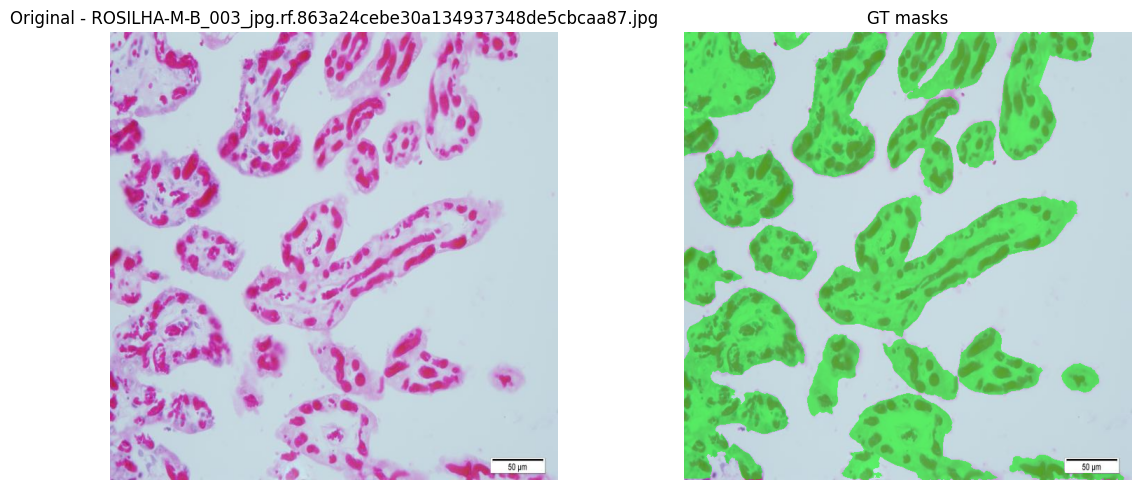

In [4]:
display(Markdown('## Tabela 1 - Dados do split'))
split_df = pd.DataFrame([
    {'Split': 'train', 'Images': len(list_images(TRAIN_IMAGES)), 'Instances': count_instances(TRAIN_LABELS, TRAIN_IMAGES)},
    {'Split': 'valid', 'Images': len(list_images(VAL_IMAGES)), 'Instances': count_instances(VAL_LABELS, VAL_IMAGES)},
])
display(split_df)

display(Markdown('## Exemplo visual GT (sem IA)'))
sample_path = list_images(VAL_IMAGES)[0]
img = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
gt_masks = parse_gt_masks(VAL_LABELS / f'{sample_path.stem}.txt', w, h)
overlay = img.copy()
for gm in gt_masks:
    overlay[gm > 0] = (overlay[gm > 0] * 0.45 + np.array([0, 255, 0]) * 0.55).astype(np.uint8)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img); ax[0].set_title(f'Original - {sample_path.name}'); ax[0].axis('off')
ax[1].imshow(overlay); ax[1].set_title('GT masks'); ax[1].axis('off')
plt.tight_layout(); plt.show()


In [5]:
def parse_args_yaml(args_path: Path | None) -> Dict[str, object]:
    if args_path is None or not Path(args_path).exists():
        return {'Run': RUN_NAME, 'Modelo': champion.get('model_family', ''), 'Epochs': '-', 'Batch': '-', 'ImgSz': '-', 'Retina_Masks': '-'}
    cfg = yaml.safe_load(Path(args_path).read_text(encoding='utf-8'))
    return {
        'Run': RUN_NAME,
        'Modelo': cfg.get('model', champion.get('model_family', '')),
        'Epochs': cfg.get('epochs', '-'),
        'Batch': cfg.get('batch', '-'),
        'ImgSz': cfg.get('imgsz', '-'),
        'Retina_Masks': cfg.get('retina_masks', '-'),
    }


display(Markdown('## Tabela 2 - Configuracao do melhor run'))
display(pd.DataFrame([parse_args_yaml(ARGS_YAML)]))

display(Markdown('## Tabela 3 - Comparacao YOLO11s vs YOLO11m'))
if not leaderboard_df.empty:
    cols = [c for c in ['variant', 'model_family', 'conf', 'f1', 'mean_iou', 'area_rel_error', 'weighted_score'] if c in leaderboard_df.columns]
    display(leaderboard_df[cols].round(4))
else:
    print('yolo_model_leaderboard.csv nao encontrado.')

display(Markdown('## Tabela 4 - Selecao do checkpoint campeao'))
display(pd.DataFrame([{
    'Modelo': champion.get('model_family', ''),
    'Run': champion.get('variant', ''),
    'Best_Conf': champion.get('best_conf', ''),
    'Checkpoint': champion.get('checkpoint', ''),
    'Weighted_Score': champion.get('weighted_score', ''),
}]))


## Tabela 2 - Configuracao do melhor run

,Run,Modelo,Epochs,Batch,ImgSz,Retina_Masks
0,placentas_v11_aug_v2,yolo11s-seg.pt,120,2,640,True


## Tabela 3 - Comparacao YOLO11s vs YOLO11m

,variant,model_family,conf,f1,mean_iou,area_rel_error,weighted_score
0,placentas_v11_aug_v2,yolo11s_seg,0.4600,0.8888,0.8809,0.0062,0.9074
1,placentas_v11m_v2.13,yolo11m_seg,0.4655,0.8854,0.8818,0.0150,0.9008


## Tabela 4 - Selecao do checkpoint campeao

,Modelo,Run,Best_Conf,Checkpoint,Weighted_Score
0,yolo11s_seg,placentas_v11_aug_v2,0.46,D:\projeto_placentas_clayton\dev\projeto-place...,0.90742


In [6]:
def benchmark_yolo_inference(model: YOLO, img_paths: List[Path], conf_thr: float, imgsz: int = 640, repeats: int = 3, warmup: int = 1) -> Dict[str, float]:
    for _ in range(warmup):
        for p in img_paths:
            model.predict(str(p), conf=conf_thr, imgsz=imgsz, retina_masks=True, verbose=False)
    timings = []
    peak_mem_mb = np.nan
    for _ in range(repeats):
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
        t0 = time.perf_counter()
        for p in img_paths:
            model.predict(str(p), conf=conf_thr, imgsz=imgsz, retina_masks=True, verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            peak_mem_mb = torch.cuda.max_memory_allocated() / (1024.0 ** 2)
        timings.append(time.perf_counter() - t0)
    mean_elapsed = float(np.mean(timings))
    n = max(len(img_paths), 1)
    return {
        'elapsed_sec_mean': mean_elapsed, 'elapsed_sec_std': float(np.std(timings)),
        'sec_per_image': mean_elapsed / n, 'images_per_sec': n / mean_elapsed if mean_elapsed > 0 else 0.0,
        'peak_vram_mb_measured': peak_mem_mb, 'repeats': repeats, 'warmup': warmup,
    }


def evaluate_checkpoint(weights_path: Path, conf_thr: float, run_name: str, imgsz: int = 640):
    model = YOLO(str(weights_path))
    img_paths = list_images(VAL_IMAGES)
    infer_bench = benchmark_yolo_inference(model, img_paths, conf_thr, imgsz=imgsz)
    tp = fp = fn = 0
    ious = []
    gt_total_area = 0
    pred_total_area = 0
    pipeline_times = []
    totals_rows = []
    instance_rows = []
    iou_single_dir = SHOWCASE_ROOT / 'iou_original_overlap'
    iou_single_dir.mkdir(parents=True, exist_ok=True)
    for img_path in img_paths:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        gt_masks = parse_gt_masks(VAL_LABELS / f'{img_path.stem}.txt', w, h)
        gt_total_area += sum(int(gm.sum()) for gm in gt_masks)
        t0 = time.perf_counter()
        r = model.predict(str(img_path), conf=conf_thr, imgsz=imgsz, retina_masks=True, verbose=False)[0]
        pred_masks = resize_masks(masks_from_result(r), w, h)
        pred_total_area += sum(int(pm.sum()) for pm in pred_masks)
        pairs, used_p, used_g = greedy_match(pred_masks, gt_masks, IOU_THRESHOLD)
        pipeline_times.append(time.perf_counter() - t0)
        tp += len(pairs); fp += len(pred_masks) - len(used_p); fn += len(gt_masks) - len(used_g)
        ious.extend([p[2] for p in pairs])
        gt_area_total = int(sum(int(gm.sum()) for gm in gt_masks))
        pred_area_total = int(sum(int(pm.sum()) for pm in pred_masks))
        area_diff_pct = ((pred_area_total - gt_area_total) / max(gt_area_total, 1)) * 100.0
        gt_union = np.zeros((h, w), dtype=np.uint8)
        pred_union = np.zeros((h, w), dtype=np.uint8)
        for gm in gt_masks: gt_union = np.logical_or(gt_union, gm).astype(np.uint8)
        for pm in pred_masks: pred_union = np.logical_or(pred_union, pm).astype(np.uint8)
        overlay = img_rgb.copy()
        overlay[gt_union == 1] = (overlay[gt_union == 1] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
        overlay[pred_union == 1] = (overlay[pred_union == 1] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
        overlap = np.logical_and(gt_union, pred_union)
        overlay[overlap] = (overlay[overlap] * 0.5 + np.array([255, 255, 0]) * 0.5).astype(np.uint8)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(overlay); axes[1].set_title('Overlap (GT verde, IA vermelho, intersecao amarelo)'); axes[1].axis('off')
        fig.suptitle(f'{img_path.stem} | CE={len(pred_masks)-len(gt_masks)} | AD={area_diff_pct:.1f}%')
        fig.tight_layout()
        fig.savefig(iou_single_dir / f'original_overlap_{img_path.stem}.png', dpi=140, bbox_inches='tight')
        plt.close(fig)
        totals_rows.append({'Image': img_path.name, 'GT_Count': len(gt_masks), 'AI_Count': len(pred_masks), 'Matched': len(pairs),
            'FP': len(pred_masks) - len(pairs), 'FN': len(gt_masks) - len(pairs), 'Count_Error': len(pred_masks) - len(gt_masks),
            'GT_Area_px': gt_area_total, 'AI_Area_px': pred_area_total, 'GT_Area_um2': gt_area_total * AREA_FACTOR,
            'AI_Area_um2': pred_area_total * AREA_FACTOR, 'Area_Diff_pct': area_diff_pct, 'Pipeline_ms': pipeline_times[-1] * 1000.0})
        for p_idx, g_idx, score in pairs:
            p_area = int(pred_masks[p_idx].sum()); g_area = int(gt_masks[g_idx].sum())
            instance_rows.append({'Image': img_path.name, 'Match_Type': 'TP', 'AI_Index': p_idx, 'GT_Index': g_idx, 'IoU': score,
                'GT_Area_px': g_area, 'AI_Area_px': p_area, 'GT_Area_um2': g_area * AREA_FACTOR, 'AI_Area_um2': p_area * AREA_FACTOR})
        for p_idx, pm in enumerate(pred_masks):
            if p_idx in used_p: continue
            p_area = int(pm.sum())
            instance_rows.append({'Image': img_path.name, 'Match_Type': 'FP', 'AI_Index': p_idx, 'GT_Index': -1, 'IoU': 0.0,
                'GT_Area_px': 0, 'AI_Area_px': p_area, 'GT_Area_um2': 0.0, 'AI_Area_um2': p_area * AREA_FACTOR})
        for g_idx, gm in enumerate(gt_masks):
            if g_idx in used_g: continue
            g_area = int(gm.sum())
            instance_rows.append({'Image': img_path.name, 'Match_Type': 'FN', 'AI_Index': -1, 'GT_Index': g_idx, 'IoU': 0.0,
                'GT_Area_px': g_area, 'AI_Area_px': 0, 'GT_Area_um2': g_area * AREA_FACTOR, 'AI_Area_um2': 0.0})
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2.0 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    mean_iou = float(np.mean(ious)) if ious else 0.0
    area_rel_error = abs(pred_total_area - gt_total_area) / max(gt_total_area, 1)
    pipeline_total = float(np.sum(pipeline_times))
    summary = {
        'run_name': run_name, 'conf': conf_thr, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn),
        'precision': precision, 'recall': recall, 'f1': f1, 'mean_iou': mean_iou,
        'gt_total_area_px': int(gt_total_area), 'pred_total_area_px': int(pred_total_area), 'area_rel_error': area_rel_error,
        'sec_per_image': infer_bench['sec_per_image'], 'images_per_sec': infer_bench['images_per_sec'],
        'infer_elapsed_sec_mean': infer_bench['elapsed_sec_mean'], 'infer_elapsed_sec_std': infer_bench['elapsed_sec_std'],
        'pipeline_sec_per_image': pipeline_total / max(len(img_paths), 1),
        'pipeline_images_per_sec': (len(img_paths) / pipeline_total) if pipeline_total > 0 else 0.0,
        'peak_vram_mb_measured': infer_bench['peak_vram_mb_measured'],
        'benchmark_repeats': infer_bench['repeats'], 'benchmark_warmup': infer_bench['warmup'],
    }
    return summary, pd.DataFrame(totals_rows), pd.DataFrame(instance_rows)


summary_json = SHOWCASE_ROOT / 'showcase_summary.json'
totals_csv = SHOWCASE_ROOT / 'placenta_totals_report_yolo_showcase.csv'
inst_csv = SHOWCASE_ROOT / 'placenta_instance_report_yolo_showcase.csv'

if RUN_CHECKPOINT_EVAL:
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f'Checkpoint nao encontrado: {CHECKPOINT_PATH}')
    summary, totals_df, inst_df = evaluate_checkpoint(CHECKPOINT_PATH, BEST_CONF, RUN_NAME)
    gt_count_total = int(totals_df['GT_Count'].sum()); ai_count_total = int(totals_df['AI_Count'].sum())
    summary['mean_abs_count_error'] = float(totals_df['Count_Error'].abs().mean())
    summary['mean_count_error'] = float(totals_df['Count_Error'].mean())
    summary['count_rel_error'] = abs(ai_count_total - gt_count_total) / max(gt_count_total, 1)
    summary['mean_abs_area_diff_pct'] = float(totals_df['Area_Diff_pct'].abs().mean())
    summary['mean_area_diff_pct'] = float(totals_df['Area_Diff_pct'].mean())
    summary['gt_count_total'] = gt_count_total; summary['ai_count_total'] = ai_count_total
    totals_df.to_csv(totals_csv, index=False); inst_df.to_csv(inst_csv, index=False)
    summary_json.write_text(json.dumps(summary, indent=2), encoding='utf-8')
else:
    summary = json.loads(summary_json.read_text(encoding='utf-8'))
    totals_df = pd.read_csv(totals_csv); inst_df = pd.read_csv(inst_csv)

display(Markdown('## Tabela 5 - Resumo executivo de metricas'))
display(pd.DataFrame([{'F1_instancia': summary['f1'], 'Mean_IoU': summary['mean_iou'], 'Sec_por_imagem_modelo': summary['sec_per_image'],
    'Img_por_seg_modelo': summary['images_per_sec'], 'VRAM_MB_medida': summary['peak_vram_mb_measured']}]).round(4))

display(Markdown('## Erro medio no val (contagem e area)'))
display(pd.DataFrame([{'Erro_medio_abs_contagem_por_imagem': summary.get('mean_abs_count_error', totals_df['Count_Error'].abs().mean()),
    'Erro_medio_contagem_por_imagem': summary.get('mean_count_error', totals_df['Count_Error'].mean()),
    'Erro_contagem_total_val_pct': summary.get('count_rel_error', np.nan) * 100.0,
    'Erro_medio_abs_area_por_imagem_pct': summary.get('mean_abs_area_diff_pct', totals_df['Area_Diff_pct'].abs().mean()),
    'Erro_area_total_val_pct': summary['area_rel_error'] * 100.0,
    'GT_Count_total': summary.get('gt_count_total', totals_df['GT_Count'].sum()),
    'AI_Count_total': summary.get('ai_count_total', totals_df['AI_Count'].sum())}]).round(4))

display(Markdown('## Tabela 6 - Metricas recalculadas (checkpoint carregado)'))
display(pd.DataFrame([summary])[['run_name', 'conf', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1', 'mean_iou', 'gt_total_area_px', 'pred_total_area_px', 'area_rel_error', 'sec_per_image', 'images_per_sec']].round(4))


## Tabela 5 - Resumo executivo de metricas

,F1_instancia,Mean_IoU,Sec_por_imagem_modelo,Img_por_seg_modelo,VRAM_MB_medida
0,0.8888,0.8809,0.032,31.289,266.9199


## Erro medio no val (contagem e area)

,Erro_medio_abs_contagem_por_imagem,Erro_medio_contagem_por_imagem,Erro_contagem_total_val_pct,Erro_medio_abs_area_por_imagem_pct,Erro_area_total_val_pct,GT_Count_total,AI_Count_total
0,1.7037,-1.1852,3.7559,8.8825,0.6176,852,820


## Tabela 6 - Metricas recalculadas (checkpoint carregado)

,run_name,conf,tp,fp,fn,precision,recall,f1,mean_iou,gt_total_area_px,pred_total_area_px,area_rel_error,sec_per_image,images_per_sec
0,placentas_v11_aug_v2,0.46,743,77,109,0.9061,0.8721,0.8888,0.8809,4105301,4130657,0.0062,0.032,31.289


In [7]:
display(Markdown('## Tabela 7 - Relatorio por imagem'))
table6_cols = ['Image', 'GT_Count', 'AI_Count', 'Matched', 'FP', 'FN', 'Count_Error', 'GT_Area_um2', 'AI_Area_um2', 'Area_Diff_pct', 'Pipeline_ms']
table6_df = totals_df[table6_cols].copy()
table6_df['abs_count_error'] = table6_df['Count_Error'].abs()
table6_df['abs_area_diff_pct'] = table6_df['Area_Diff_pct'].abs()
table6_df = table6_df.sort_values(['abs_count_error', 'abs_area_diff_pct'], ascending=[False, False]).drop(columns=['abs_count_error', 'abs_area_diff_pct'])
display(table6_df.round(4))

display(Markdown('## Tabela 8 - Resumo por instancia'))
type_counts = inst_df['Match_Type'].value_counts().to_dict(); n_total = len(inst_df)
table7_df = pd.DataFrame([{'Instancias_TP': type_counts.get('TP', 0), 'Instancias_FP': type_counts.get('FP', 0), 'Instancias_FN': type_counts.get('FN', 0),
    'TP_pct': (type_counts.get('TP', 0) / max(n_total, 1)) * 100.0, 'FP_pct': (type_counts.get('FP', 0) / max(n_total, 1)) * 100.0,
    'FN_pct': (type_counts.get('FN', 0) / max(n_total, 1)) * 100.0, 'Mean_IoU_TP': inst_df.loc[inst_df['Match_Type'] == 'TP', 'IoU'].mean() if n_total else 0.0}])
display(table7_df.round(4))
best3 = table6_df.assign(score=(table6_df['Count_Error'].abs() + table6_df['Area_Diff_pct'].abs())).sort_values('score', ascending=True).head(3).drop(columns=['score'])
worst3 = table6_df.assign(score=(table6_df['Count_Error'].abs() + table6_df['Area_Diff_pct'].abs())).sort_values('score', ascending=False).head(3).drop(columns=['score'])
display(Markdown('## Top 3 melhores imagens')); display(best3.round(4))
display(Markdown('## Top 3 piores imagens')); display(worst3.round(4))


## Tabela 7 - Relatorio por imagem

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
11,TORDILHA-D_006_jpg.rf.d879d44ef1add0b327aa39f6...,35,29,25,4,10,-6,106583.2369,70541.0880,-33.8160,1790.5637
15,TOSTADA-G_009_jpg.rf.506f019d1e54427e5f8151078...,42,38,37,1,5,-4,86944.9267,89927.1798,3.4300,2818.0263
21,ZAINA-679-B_010_jpg.rf.4a3c6644c7fdcdc349eaceb...,38,42,35,7,3,4,92368.8272,94099.6335,1.8738,2937.0192
19,TP-G_008_jpg.rf.7ce2f84776589571f8d07c60f1c4e6...,33,29,28,1,5,-4,66115.9336,66445.3125,0.4982,2053.5967
10,TORDILHA-D_001_jpg.rf.36e39c15aad81283f9bcc0f8...,24,21,20,1,4,-3,104381.2693,89897.7623,-13.8756,1192.2945
20,TP-G_010_jpg.rf.5c8b394cdec2d68bae00b4eb6679ec...,37,34,32,2,5,-3,69605.0347,65578.7037,-5.7845,2371.8427
12,TORDILHA-G_009_jpg.rf.b279af9f6892d54790621c0f...,37,34,32,2,5,-3,71641.1073,67627.7971,-5.6020,2523.5330
25,ZAZA-G_010_jpg.rf.cd14098445a0a54c10014aaa7d8f...,29,26,26,0,3,-3,55770.6404,55095.9684,-1.2097,1479.1219
23,ZAZA-B_008_jpg.rf.92ad451b5359143319a46e599a02...,28,26,17,9,11,-2,95175.5401,125776.9097,32.1526,1307.1741
26,ZAZA-G_012_jpg.rf.b65fca463e4411032a599acd7494...,35,33,30,3,5,-2,75149.4985,82412.7122,9.6650,2037.9482


## Tabela 8 - Resumo por instancia

,Instancias_TP,Instancias_FP,Instancias_FN,TP_pct,FP_pct,FN_pct,Mean_IoU_TP
0,743,77,109,79.9785,8.2885,11.733,0.8809


## Top 3 melhores imagens

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
17,TP-B_001_jpg.rf.476ac40460a2659ffbad7973abf99d...,31,29,28,1,3,-2,66937.6929,67215.4707,0.4150,1726.1226
22,ZAINA-679-B_011_jpg.rf.27d46a055eff6f5810ec4c5...,24,24,23,1,1,0,108871.5278,111735.6289,2.6307,1271.6143
0,ROSILHA-M-B_003_jpg.rf.863a24cebe30a134937348d...,20,20,16,4,4,0,89225.0193,91791.0880,2.8760,1095.5899


## Top 3 piores imagens

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
11,TORDILHA-D_006_jpg.rf.d879d44ef1add0b327aa39f6...,35,29,25,4,10,-6,106583.2369,70541.0880,-33.8160,1790.5637
23,ZAZA-B_008_jpg.rf.92ad451b5359143319a46e599a02...,28,26,17,9,11,-2,95175.5401,125776.9097,32.1526,1307.1741
5,ROSILHA-M-G_005_jpg.rf.afae2fb85329c0fe56679d5...,13,13,10,3,3,0,76879.3403,97860.2431,27.2907,561.1222


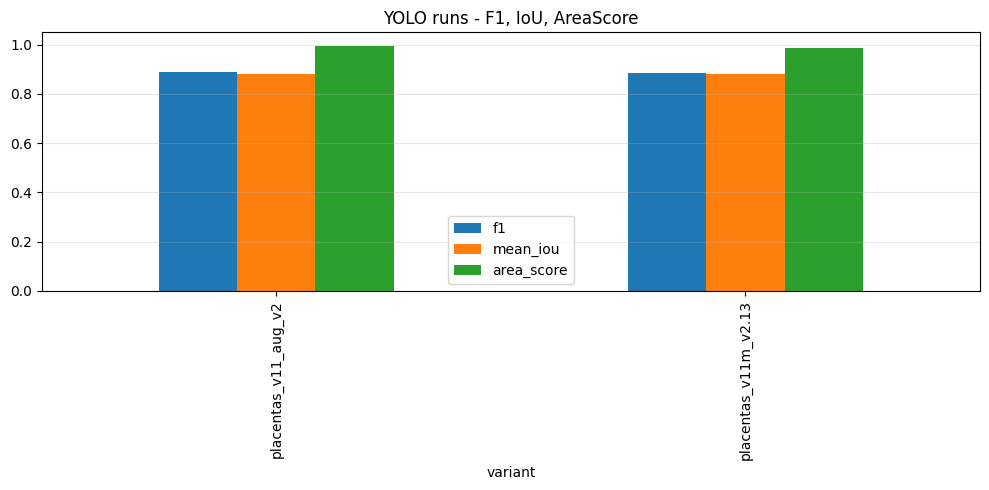

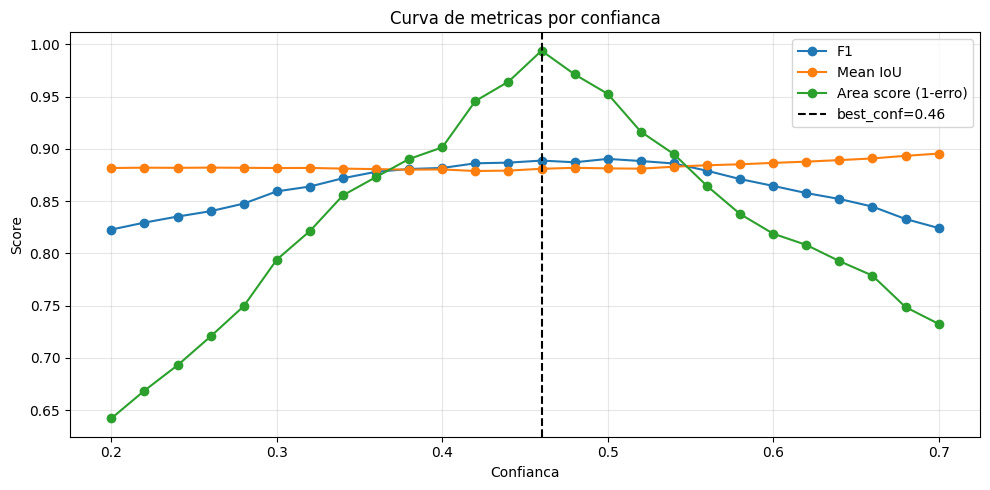

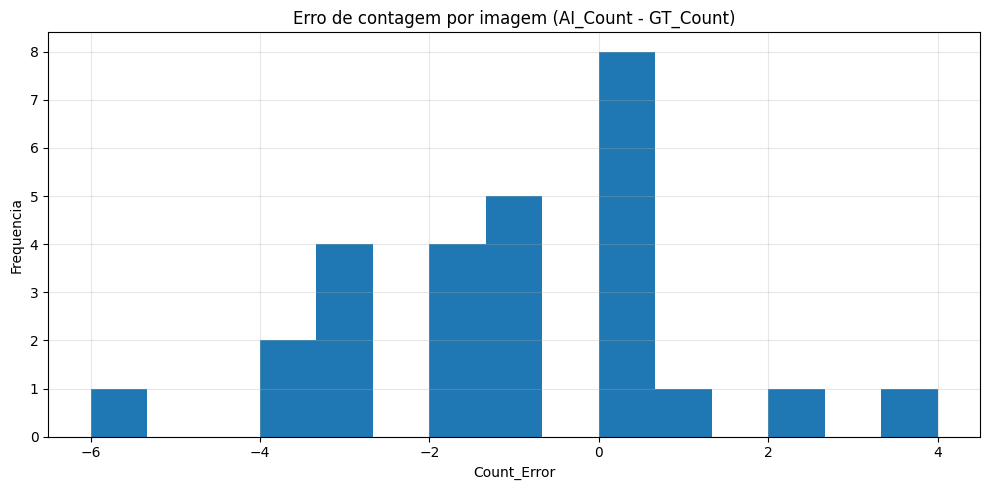

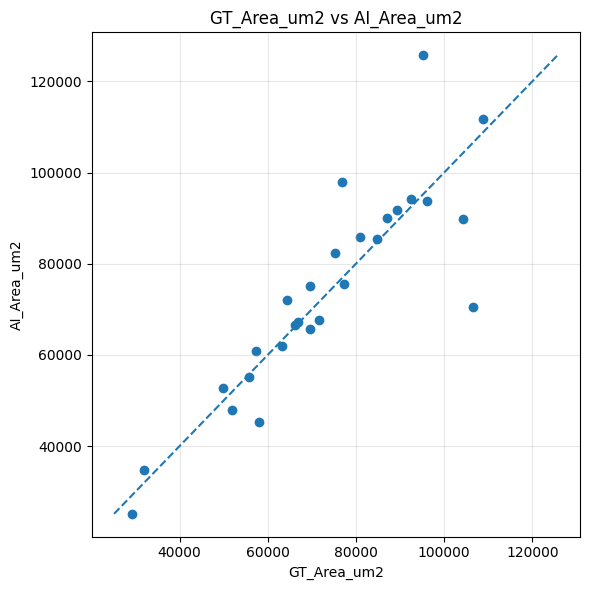

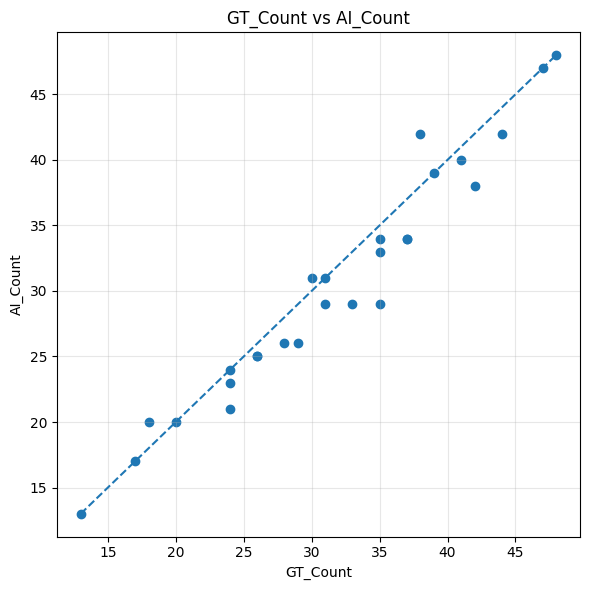

In [8]:
def save_current_fig(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=140, bbox_inches='tight')

sweep_df = pd.read_csv(SWEEP_CSV) if SWEEP_CSV.exists() else pd.DataFrame()
if not leaderboard_df.empty:
    bars_df = leaderboard_df[['variant', 'f1', 'mean_iou', 'area_rel_error']].copy()
    bars_df['area_score'] = 1.0 - bars_df['area_rel_error']
    bars_df = bars_df.set_index('variant')
    fig = bars_df[['f1', 'mean_iou', 'area_score']].plot(kind='bar', figsize=(10, 5), title='YOLO runs - F1, IoU, AreaScore').get_figure()
    plt.ylim(0.0, 1.05); plt.grid(axis='y', alpha=0.3); plt.tight_layout()
    save_current_fig(FIG_ROOT / 'run_comparison_bars.png'); plt.show()
if not sweep_df.empty:
    sweep_plot = sweep_df.sort_values('conf').drop_duplicates(subset=['conf'], keep='last').copy()
    plt.figure(figsize=(10, 5))
    plt.plot(sweep_plot['conf'], sweep_plot['f1'], marker='o', label='F1')
    plt.plot(sweep_plot['conf'], sweep_plot['mean_iou'], marker='o', label='Mean IoU')
    if 'area_rel_error' in sweep_plot.columns:
        plt.plot(sweep_plot['conf'], 1.0 - sweep_plot['area_rel_error'], marker='o', label='Area score (1-erro)')
    plt.axvline(BEST_CONF, linestyle='--', color='black', label=f'best_conf={BEST_CONF:.2f}')
    plt.title('Curva de metricas por confianca'); plt.xlabel('Confianca'); plt.ylabel('Score')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    save_current_fig(FIG_ROOT / 'conf_sweep_curve.png'); plt.show()
plt.figure(figsize=(10, 5)); plt.hist(totals_df['Count_Error'], bins=15)
plt.title('Erro de contagem por imagem (AI_Count - GT_Count)'); plt.xlabel('Count_Error'); plt.ylabel('Frequencia')
plt.grid(alpha=0.3); plt.tight_layout(); save_current_fig(FIG_ROOT / 'count_error_hist.png'); plt.show()
plt.figure(figsize=(6, 6)); x = totals_df['GT_Area_um2'].to_numpy(); y = totals_df['AI_Area_um2'].to_numpy()
plt.scatter(x, y); mn, mx = float(min(x.min(), y.min())), float(max(x.max(), y.max())); plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('GT_Area_um2 vs AI_Area_um2'); plt.xlabel('GT_Area_um2'); plt.ylabel('AI_Area_um2')
plt.grid(alpha=0.3); plt.tight_layout(); save_current_fig(FIG_ROOT / 'area_scatter.png'); plt.show()
plt.figure(figsize=(6, 6)); x = totals_df['GT_Count'].to_numpy(); y = totals_df['AI_Count'].to_numpy()
plt.scatter(x, y); mn, mx = float(min(x.min(), y.min())), float(max(x.max(), y.max())); plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('GT_Count vs AI_Count'); plt.xlabel('GT_Count'); plt.ylabel('AI_Count')
plt.grid(alpha=0.3); plt.tight_layout(); save_current_fig(FIG_ROOT / 'count_scatter.png'); plt.show()


In [9]:
display(Markdown('## Tabela 9 - Inferencia e hardware'))
rows = [
    {'Cenario': 'modelo_sistema (usar este)', 'O_que_mede': 'predict() com warmup + CUDA sync',
     'Sec_por_imagem': summary.get('sec_per_image', np.nan), 'Img_por_seg': summary.get('images_per_sec', np.nan),
     'Peak_GPU_MB': summary.get('peak_vram_mb_measured', np.nan), 'Conf': summary.get('conf', np.nan)},
    {'Cenario': 'pipeline_analise', 'O_que_mede': 'predict + mascaras + match + PNG',
     'Sec_por_imagem': summary.get('pipeline_sec_per_image', np.nan), 'Img_por_seg': summary.get('pipeline_images_per_sec', np.nan),
     'Peak_GPU_MB': np.nan, 'Conf': summary.get('conf', np.nan)},
]
display(pd.DataFrame(rows).round(4))


## Tabela 9 - Inferencia e hardware

,Cenario,O_que_mede,Sec_por_imagem,Img_por_seg,Peak_GPU_MB,Conf
0,modelo_sistema (usar este),predict() com warmup + CUDA sync,0.0320,31.2890,266.9199,0.46
1,pipeline_analise,predict + mascaras + match + PNG,2.0014,0.4996,NaN,0.46


## Imagens individuais - Original x Overlap

,arquivo,caminho
0,original_overlap_ROSILHA-M-B_003_jpg.rf.863a24...,D:\projeto_placentas_clayton\dev\projeto-place...
1,original_overlap_ROSILHA-M-B_009_jpg.rf.d2aa88...,D:\projeto_placentas_clayton\dev\projeto-place...
2,original_overlap_ROSILHA-M-D_006_jpg.rf.de7108...,D:\projeto_placentas_clayton\dev\projeto-place...
3,original_overlap_ROSILHA-M-D_009_jpg.rf.b52035...,D:\projeto_placentas_clayton\dev\projeto-place...
4,original_overlap_ROSILHA-M-G_001_jpg.rf.3dab74...,D:\projeto_placentas_clayton\dev\projeto-place...
5,original_overlap_ROSILHA-M-G_005_jpg.rf.afae2f...,D:\projeto_placentas_clayton\dev\projeto-place...
6,original_overlap_ROSILHA-M-G_017_jpg.rf.85fc7b...,D:\projeto_placentas_clayton\dev\projeto-place...
7,original_overlap_TORDILHA-B_009_jpg.rf.5902113...,D:\projeto_placentas_clayton\dev\projeto-place...
8,original_overlap_TORDILHA-B_010_jpg.rf.6981240...,D:\projeto_placentas_clayton\dev\projeto-place...
9,original_overlap_TORDILHA-B_012_jpg.rf.0b5caaf...,D:\projeto_placentas_clayton\dev\projeto-place...


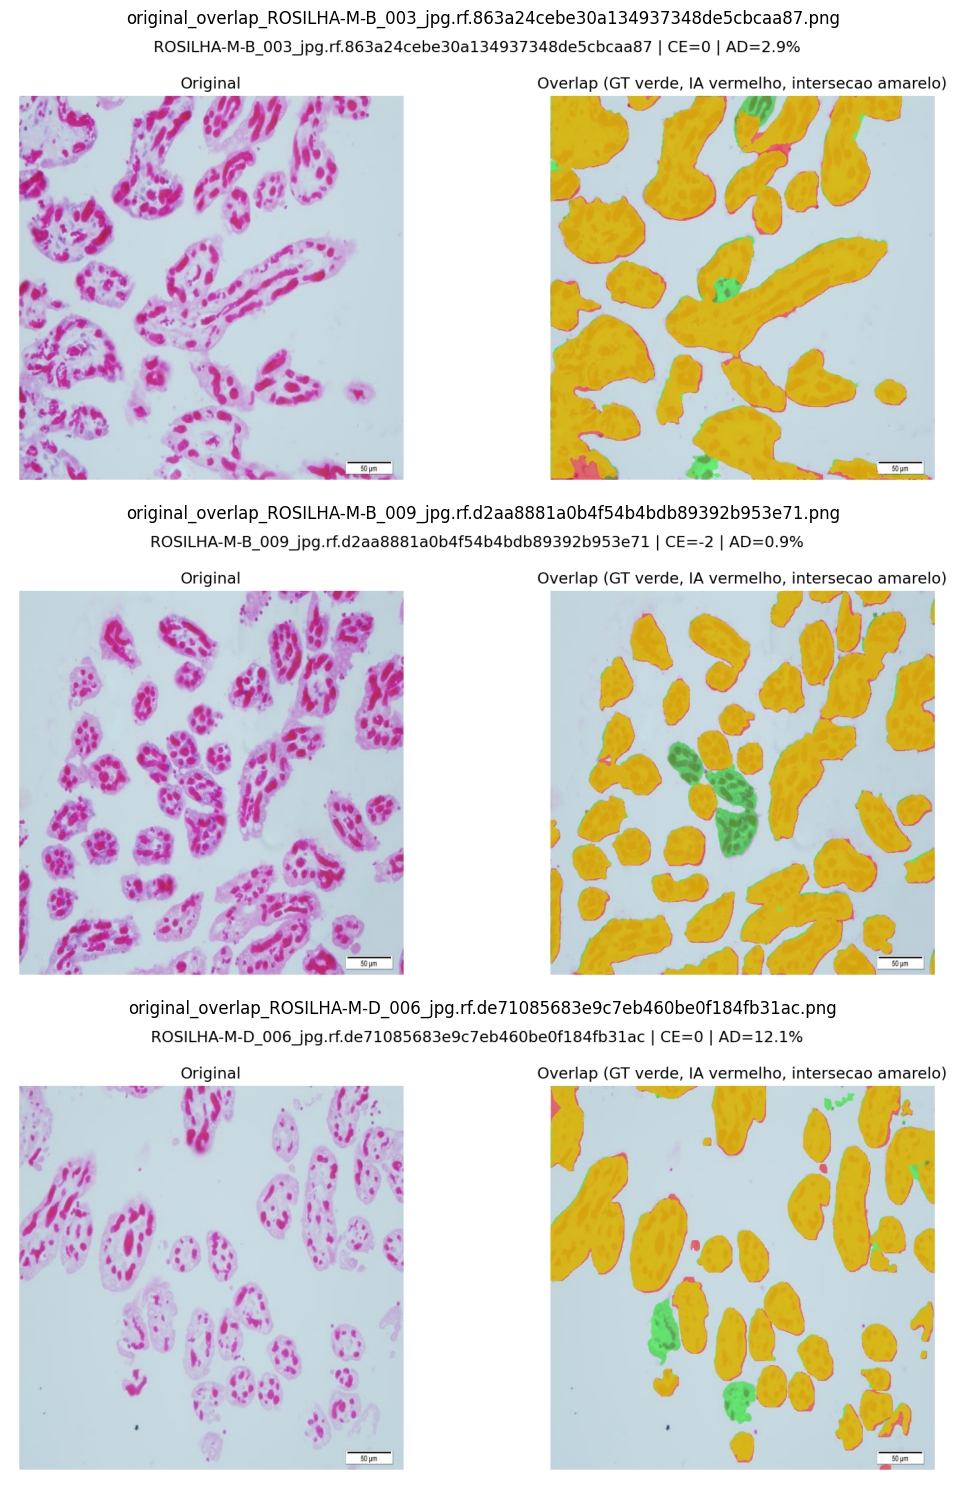

Pasta imagens individuais: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase\iou_original_overlap
Figuras exportadas em: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase\figures
Resumo JSON: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase\showcase_summary.json
Totais CSV: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase\placenta_totals_report_yolo_showcase.csv
Instancias CSV: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_yolo11s_opt_v1\artifacts\showcase\placenta_instance_report_yolo_showcase.csv


In [10]:
display(Markdown('## Imagens individuais - Original x Overlap'))
iou_single_dir = SHOWCASE_ROOT / 'iou_original_overlap'
iou_files = sorted(iou_single_dir.glob('original_overlap_*.png'))
if len(iou_files) == 0:
    print('Nenhuma imagem individual encontrada. Rode novamente a celula de avaliacao do checkpoint.')
else:
    display(pd.DataFrame({'arquivo': [p.name for p in iou_files], 'caminho': [str(p) for p in iou_files]}))
    preview_n = min(3, len(iou_files))
    fig, axes = plt.subplots(preview_n, 1, figsize=(14, 5 * preview_n))
    if preview_n == 1: axes = [axes]
    for ax, p in zip(axes, iou_files[:preview_n]):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB); ax.imshow(img); ax.set_title(p.name); ax.axis('off')
    plt.tight_layout(); plt.show()
print('Pasta imagens individuais:', iou_single_dir)
print('Figuras exportadas em:', FIG_ROOT)
print('Resumo JSON:', summary_json)
print('Totais CSV:', totals_csv)
print('Instancias CSV:', inst_csv)
